# Pipeline de moderacion (POC end-to-end)

Sistema completo de bajo costo. Funcion de entrada: `moderate(picture_url) -> {has_infraction, evidence}`.

```
imagen
 -> [OCR local (RapidOCR, sin Google)]  ¿hay texto?
       no  -> LIMPIO (no usa VLM)
 -> [router (LLM de texto + backstop)]  ¿lenguaje promo/delivery/badge?
       no  -> LIMPIO (no usa VLM)
 -> [VLM (Qwen2.5-VL)]                  decide overlay-vs-fisico + evidencia
```
El texto enruta (barato); la imagen decide (VLM, solo el residuo).

In [1]:
import base64
import io
import sys
from pathlib import Path

import pandas as pd
from PIL import Image as PILImage
from IPython.display import HTML

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
GOLDEN_DIR = ROOT / "data" / "golden"
pd.set_option("display.max_colwidth", None)

## 1. Instanciar el pipeline

Carga OCR local + router (LLM de texto) + VLM. La primera vez baja los modelos.

In [12]:
from moderation import ModerationPipeline

# VLM por defecto = Qwen2.5-VL-3B (rapido). Para mejor calidad: ModerationPipeline(vlm_model="mlx-community/Qwen2.5-VL-7B-Instruct-4bit")
pipe = ModerationPipeline(vlm_model="mlx-community/Qwen2.5-VL-7B-Instruct-4bit")

Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

## 2. Demo: `moderate()` sobre ejemplos

Casos representativos del golden: infraccion real, limpia sin texto, texto fisico (concesionario), tapa de libro.

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


imagen,verdad,pred,etapa,evidence
,True,True OK,vlm,mercado livre pronta entrega
,False,False OK,ocr,"El OCR local no detecto texto en la imagen, por lo que no hay overlay promocional, de entr"
,False,True MAL,vlm,"el texto ""pronta entrega"" en la imagen"
,False,False OK,vlm,el texto impreso en la tapa del libro

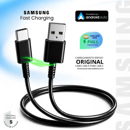
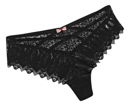
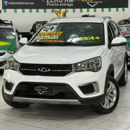
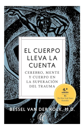

In [16]:
g = pd.read_parquet(GOLDEN_DIR / "golden_set.parquet")
man = pd.read_parquet(GOLDEN_DIR / "images_manifest.parquet")
g = g.merge(man[["picture_url", "local_path"]], on="picture_url")
g["txt"] = g["ocr_text"].fillna("").astype(str)


def pick(cond):
    s = g[cond]
    return s.iloc[0] if len(s) else None


ejemplos = [
    pick(g["txt"].str.contains("FULL", case=False) & (g["final_label"].astype("boolean") == True)),
    pick(g["txt"].str.strip().eq("") & (g["final_label"].astype("boolean") == False)),
    pick(g["txt"].str.contains("ratsmultimarcas", case=False)),
    pick(g["txt"].str.contains("bestseller|best seller|edicion", case=False) & (g["final_label"].astype("boolean") == False)),
]
ejemplos = [e for e in ejemplos if e is not None]


def thumb(path, w=130):
    im = PILImage.open(path).convert("RGB")
    im.thumbnail((w, w))
    b = io.BytesIO()
    im.save(b, format="PNG")
    return base64.b64encode(b.getvalue()).decode()


rows = "<tr><th>imagen</th><th>verdad</th><th>pred</th><th>etapa</th><th>evidence</th></tr>"
for r in ejemplos:
    path = ROOT / r["local_path"]
    out = pipe.moderate(image_path=path)
    ok = "OK" if bool(out["has_infraction"]) == bool(r["final_label"]) else "MAL"
    rows += (f"<tr><td><img src='data:image/png;base64,{thumb(path)}'></td>"
             f"<td>{bool(r['final_label'])}</td>"
             f"<td>{out['has_infraction']} {ok}</td>"
             f"<td>{out['stage']}</td>"
             f"<td>{str(out['evidence'])[:90]}</td></tr>")
HTML(f"<table>{rows}</table>")

## 3. Probar con una URL cualquiera

El contrato del reto: recibe `picture_url`, devuelve el diagnostico.

In [18]:
url = g.iloc[0]["picture_url"]
pipe.moderate(picture_url="https://img.magnific.com/vector-premium/tshirt-black-friday-deal_1083548-22887.jpg?semt=ais_hybrid&w=740&q=80")

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


{'has_infraction': True,
 'evidence': 'el texto "BLACK FRIDAY = DEAL =" en la camiseta',
 'reason': 'promo',
 'confidence': 'high',
 'stage': 'vlm',
 'ocr_text': 'BLACK FRIDAY DEAL =',
 'latency_ms': 27189.2,
 'stage_ms': {'resolve_ms': 891.8378343805671,
  'ocr_ms': 342.6033752039075,
  'router_ms': 0.03424985334277153,
  'vlm_ms': 25954.74312501028}}

## 4. Evaluacion end-to-end

Se corre por separado (usa GPU/tiempo), desde la raiz del proyecto:

```
VLM_MODEL=mlx-community/Qwen2.5-VL-7B-Instruct-4bit python scripts/eval_pipeline.py all
```

Genera `pipeline_preds.parquet`. La celda siguiente lee ese resultado y muestra el ahorro por etapa y las metricas del sistema completo vs el legacy.

In [ ]:
import numpy as np

preds_path = GOLDEN_DIR / "pipeline_preds.parquet"
if preds_path.exists():
    p = pd.read_parquet(preds_path)

    print("=== etapa donde se decidio (ahorro de VLM) ===")
    print(p["stage"].value_counts(normalize=True).round(3).to_dict())

    def m(yt, yp):
        yt = yt.astype(bool).to_numpy(); yp = yp.astype(bool).to_numpy()
        tp = int((yt & yp).sum()); fp = int((~yt & yp).sum())
        fn = int((yt & ~yp).sum()); tn = int((~yt & ~yp).sum())
        P = tp / (tp + fp) if tp + fp else float("nan")
        R = tp / (tp + fn) if tp + fn else float("nan")
        return {"precision": round(P, 3), "recall": round(R, 3), "tp": tp, "fp": fp, "fn": fn, "tn": tn}

    print("\nPIPELINE:", m(p["final_label"], p["pipeline_pred"]))
    print("LEGACY  :", m(p["final_label"], p["legacy_label"]))
else:
    print("Aun no existe pipeline_preds.parquet. Corre scripts/eval_pipeline.py primero.")